## Задание
Для оценки удержания аудитории необходимо написать функцию на Python, которая рассчитывает retention игроков по дням с момента их регистрации в приложении.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from operator import attrgetter
from IPython.display import display
from scipy import stats
from math import sqrt


# ПОДГОТОВКА ДАННЫХ С РЕГИСТРАЦИЕЙ ПОЛЬЗОВАТЕЛЕЙ
df_reg = pd.read_csv("../../shared/problem1-reg_data.csv", sep = ';')

df_reg['uid'] = df_reg['uid'].astype(int)
df_reg['reg_ts'] = pd.to_datetime(df_reg['reg_ts'], unit='s')

# Проверяем данные
print("Данные регистрации пользователей")
display(df_reg.head())
print(df_reg.isna().sum(), "\n Число строк", len(df_reg), "\n Количество уникальных строк", df_reg['uid'].nunique())

# ПОДГОТОВКА ФАЙЛА С АВТОРИЗАЦИЯМИ
auth_chunks = []

for chunk in pd.read_csv("../../shared/problem1-auth_data.csv", sep = ';', chunksize=100_000):
 
    chunk['uid'] = chunk['uid'].astype(int)
    chunk['auth_ts'] = pd.to_datetime(chunk['auth_ts'], unit='s')

    auth_chunks.append(chunk[['uid', 'auth_ts']])

df_auth = pd.concat(auth_chunks, ignore_index=True)

# Проверяем данные
print('')
print("Данные авторизации пользователей")
display(df_auth.head())
print(df_auth.isna().sum(), "\n", len(df_auth), "\n Количество уникальных строк", df_auth['uid'].nunique())


Данные регистрации пользователей


,reg_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,2000-01-13 22:27:27,3
3,2000-05-28 14:19:01,4
4,2000-09-16 11:21:53,5


reg_ts    0
uid       0
dtype: int64 
 Число строк 1000000 
 Количество уникальных строк 1000000

Данные авторизации пользователей


,uid,auth_ts
0,1,1998-11-18 09:43:43
1,2,1999-07-22 22:38:09
2,2,1999-07-25 16:46:46
3,2,1999-07-31 03:50:15
4,2,1999-08-05 17:49:39


uid        0
auth_ts    0
dtype: int64 
 9601013 
 Количество уникальных строк 1000000


#### Промежуточный вывод:
Данные по регистрации и авторизации пользователей загружены, приведены в формат даты, пустых значений нет, в файле problem1-reg_data все значения уникальные.    

In [15]:
# Написание функции retention 
def retention(df_reg,         # датафрейм с регистрацией пользователей
              df_auth,        # датафрейм с авторизацией пользователей
              date_begin,     # начало периода регистрации формата YYYY-MM-DD
              date_end,       # конец периода регистрации формата YYYY-MM-DD
              days_number):   # максимальный retention по дням жизни пользователя
    """
    Рассчитывает дневной retention пользователей по когортам регистраций и строит тепловую карту.
    """
    # 1. Приводим даты
    date_begin = pd.to_datetime(date_begin)
    date_end = pd.to_datetime(date_end)

    # 2. Фильтруем регистрации
    reg = df_reg[
        (df_reg['reg_ts'] >= date_begin) &
        (df_reg['reg_ts'] <= date_end)
    ].copy()

    reg['Day_of_registration'] = reg['reg_ts'].dt.date

    # 3. Фильтруем auth по этим пользователям
    auth = df_auth[df_auth['uid'].isin(reg['uid'])]

    # 4. Merge
    data = reg[['uid', 'reg_ts', 'Day_of_registration']].merge(
        auth[['uid', 'auth_ts']],
        on='uid',
        how='left'
    )

    # 5. Считаем период (дни от регистрации)
    data['period_number'] = (
        data['auth_ts'] - data['reg_ts']
    ).dt.days

    # 6. Оставляем нужные дни
    data = data[
        (data['period_number'].notna()) &
        (data['period_number'] >= 0) &
        (data['period_number'] <= days_number)
    ]

    # 7. Размер когорты (по дню регистрации)
    cohort_size = (
        reg
        .groupby('Day_of_registration')['uid']
        .nunique()
    )

    # 8. Активные пользователи по дням
    active_users = (
        data
        .groupby(['Day_of_registration', 'period_number'])['uid']
        .nunique()
        .reset_index()
    )

    # 9. Pivot → матрица
    retention = active_users.pivot(
        index='Day_of_registration',
        columns='period_number',
        values='uid'
    )

    # 10. Делим на размер когорты
    retention = retention.divide(cohort_size, axis=0)
    
    # 11. Тепловая карта
    
    plt.figure(figsize=(12, 8))

    sns.heatmap(
        retention,
        annot=True,
        fmt='.1%',
        cmap='RdYlGn',
        mask=retention.isna()
    )

    plt.title('Daily Retention Heatmap')
    plt.xlabel('Day from registration')
    plt.ylabel('Day of registration')

    plt.tight_layout()
    plt.show()
    
    # 12. Средний retention по дням

    avg_retention = retention.mean(axis=0)

    plt.figure(figsize=(8, 5))
    plt.plot(
        avg_retention.index,
        avg_retention.values * 100,
        marker='o'
    )

    plt.title('Average Daily Retention')
    plt.xlabel('Day from registration')
    plt.ylabel('Retention, %')
    plt.xticks(avg_retention.index)
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    return retention

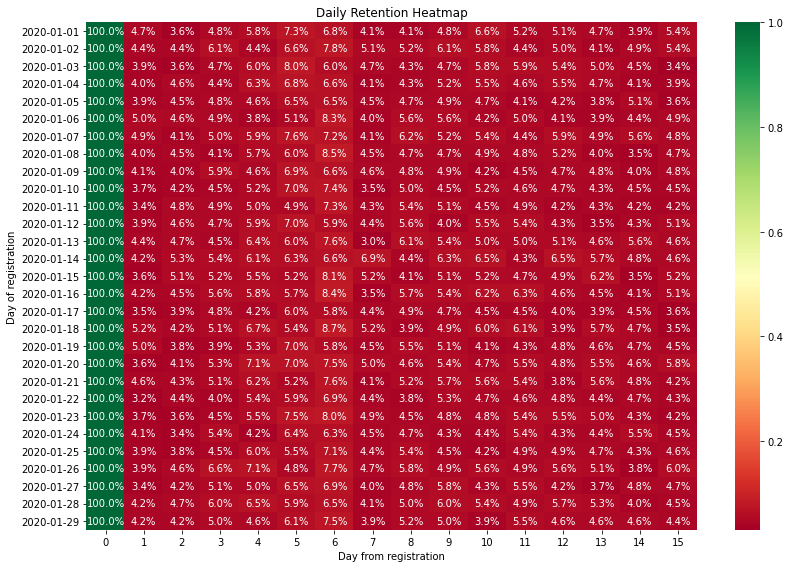

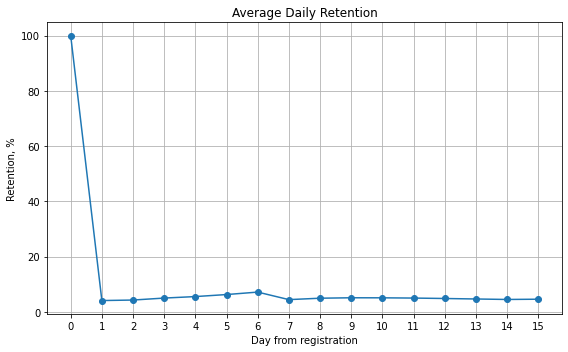

In [16]:
# Проверка работоспособности функции
retention_df = retention(
    df_reg,
    df_auth,
    date_begin='2020-01-01',
    date_end='2020-01-30',
    days_number=15
)

### Вывод

В рамках первого задания был рассчитан показатель retention игроков по дням от даты регистрации. Для анализа пользователи были сгруппированы в когорты по дню регистрации, после чего для каждого дня жизни пользователя была рассчитана доля игроков, совершивших хотя бы одну авторизацию.  
Результаты представлены в виде тепловой карты retention, которая позволяет оценить поведение отдельных когорт, а также усредненная кривая retention, отражающей среднюю динамику удержания по всем когортам. Анализ показал резкое снижение retention между днем<sub>0</sub> и днем<sub>1</sub>, что является типичным паттерном для мобильных игр, после чего наблюдается более плавное снижение показателя на последующих днях.  
#### Рекомендации
* Упростить или сократить обучающий этап;
* Добавить ранние награды, бонусы;
* Использовать push-уведомления для возврата на день<sub>1</sub>.